<a href="https://colab.research.google.com/github/InowaR/colab/blob/main/generate_points_in_polygon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Генерация точек...
Сгенерировано точек: 106
Расстояние между точками: 0.25
Отступ от периметра: 0.3


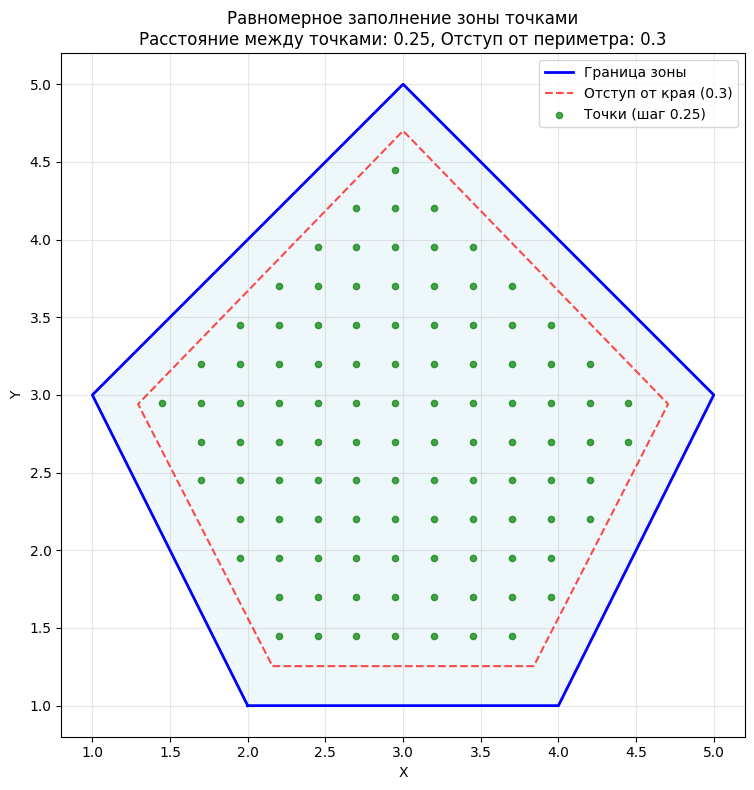


Статистика:
X: от 1.45 до 4.45
Y: от 1.45 до 4.45


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def point_in_polygon(point, polygon_vertices):
    """
    Проверяет, находится ли точка внутри многоугольника (алгоритм лучевого пересечения)
    """
    x, y = point
    n = len(polygon_vertices)
    inside = False

    p1x, p1y = polygon_vertices[0]
    for i in range(n + 1):
        p2x, p2y = polygon_vertices[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y

    return inside

def distance_to_segment(point, p1, p2):
    """
    Вычисляет минимальное расстояние от точки до отрезка
    """
    x, y = point
    x1, y1 = p1
    x2, y2 = p2

    # Вектор отрезка
    dx = x2 - x1
    dy = y2 - y1

    if dx == 0 and dy == 0:
        return np.sqrt((x - x1)**2 + (y - y1)**2)

    # Параметр ближайшей точки на отрезке
    t = ((x - x1) * dx + (y - y1) * dy) / (dx*dx + dy*dy)

    if t < 0:
        # Ближайшая точка - p1
        closest_x, closest_y = x1, y1
    elif t > 1:
        # Ближайшая точка - p2
        closest_x, closest_y = x2, y2
    else:
        # Ближайшая точка внутри отрезка
        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

    return np.sqrt((x - closest_x)**2 + (y - closest_y)**2)

def distance_to_polygon(point, polygon_vertices):
    """
    Вычисляет минимальное расстояние от точки до периметра многоугольника
    """
    min_dist = float('inf')
    n = len(polygon_vertices)

    for i in range(n):
        p1 = polygon_vertices[i]
        p2 = polygon_vertices[(i + 1) % n]
        dist = distance_to_segment(point, p1, p2)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def generate_points_in_polygon(polygon_vertices, point_spacing, margin_from_edge):
    """
    Генерирует равномерную сетку точек внутри многоугольника
    с учетом отступа от периметра и расстояния между точками

    Параметры:
    - polygon_vertices: список вершин многоугольника [(x1,y1), (x2,y2), ...]
    - point_spacing: расстояние между точками внутри зоны
    - margin_from_edge: минимальное расстояние от точки до периметра зоны
    """
    # Находим границы многоугольника
    vertices = np.array(polygon_vertices)
    min_x = np.min(vertices[:, 0])
    max_x = np.max(vertices[:, 0])
    min_y = np.min(vertices[:, 1])
    max_y = np.max(vertices[:, 1])

    # Расширяем границы с учетом отступа
    min_x -= margin_from_edge
    max_x += margin_from_edge
    min_y -= margin_from_edge
    max_y += margin_from_edge

    points = []

    # Создаем сетку с заданным шагом
    x_coords = np.arange(min_x, max_x + point_spacing, point_spacing)
    y_coords = np.arange(min_y, max_y + point_spacing, point_spacing)

    for x in x_coords:
        for y in y_coords:
            point = (x, y)

            # Проверяем, находится ли точка внутри многоугольника
            if point_in_polygon(point, polygon_vertices):
                # Проверяем расстояние до периметра
                dist_to_edge = distance_to_polygon(point, polygon_vertices)
                if dist_to_edge >= margin_from_edge:
                    points.append(point)

    return points

def visualize_points(polygon_vertices, points, margin_from_edge, point_spacing):
    """
    Визуализирует многоугольник и сгенерированные точки
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Рисуем многоугольник
    polygon_closed = np.array(polygon_vertices + [polygon_vertices[0]])
    ax.plot(polygon_closed[:, 0], polygon_closed[:, 1], 'b-', linewidth=2, label='Граница зоны')
    ax.fill(polygon_closed[:, 0], polygon_closed[:, 1], alpha=0.2, color='lightblue')

    # Рисуем внутреннюю границу (отступ от периметра)
    # Для визуализации отступа создаем уменьшенный многоугольник
    inner_polygon = shrink_polygon(polygon_vertices, margin_from_edge)
    if inner_polygon:
        inner_closed = np.array(inner_polygon + [inner_polygon[0]])
        ax.plot(inner_closed[:, 0], inner_closed[:, 1], 'r--', linewidth=1.5,
                alpha=0.7, label=f'Отступ от края ({margin_from_edge})')

    # Рисуем точки
    if points:
        points_arr = np.array(points)
        ax.scatter(points_arr[:, 0], points_arr[:, 1], c='green', s=20,
                  alpha=0.7, label=f'Точки (шаг {point_spacing})')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title(f'Равномерное заполнение зоны точками\n'
                f'Расстояние между точками: {point_spacing}, '
                f'Отступ от периметра: {margin_from_edge}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.show()

def shrink_polygon(polygon_vertices, distance):
    """
    Упрощенная версия уменьшения многоугольника для визуализации отступа
    (только для выпуклых многоугольников)
    """
    if len(polygon_vertices) < 3:
        return None

    vertices = np.array(polygon_vertices)
    center = np.mean(vertices, axis=0)

    # Для невыпуклых многоугольников эта эвристика может работать некорректно
    # Для точного уменьшения нужна более сложная логика
    shrunk_vertices = []

    for i in range(len(vertices)):
        # Вектор от центра к вершине
        vec = vertices[i] - center
        vec_norm = np.linalg.norm(vec)
        if vec_norm > distance:
            new_vec = vec * (1 - distance / vec_norm)
            shrunk_vertices.append(center + new_vec)
        else:
            return None

    # Проверяем, что после уменьшения многоугольник все еще существует
    if len(shrunk_vertices) >= 3:
        return shrunk_vertices
    return None

# Пример использования
def main():
    # Константы (меняйте здесь значения)
    POINT_SPACING = 0.25      # Расстояние между точками внутри зоны
    MARGIN_FROM_EDGE = 0.3    # Минимальное расстояние от точки до периметра зоны

    # Задаем произвольную фигуру с углами (пятиугольник)
    polygon = [
        (2, 1),
        (4, 1),
        (5, 3),
        (3, 5),
        (1, 3)
    ]

    # Генерируем точки
    print("Генерация точек...")
    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    print(f"Сгенерировано точек: {len(points)}")
    print(f"Расстояние между точками: {POINT_SPACING}")
    print(f"Отступ от периметра: {MARGIN_FROM_EDGE}")

    # Визуализируем результат
    visualize_points(polygon, points, MARGIN_FROM_EDGE, POINT_SPACING)

    # Дополнительная статистика
    if points:
        points_arr = np.array(points)
        print(f"\nСтатистика:")
        print(f"X: от {np.min(points_arr[:, 0]):.2f} до {np.max(points_arr[:, 0]):.2f}")
        print(f"Y: от {np.min(points_arr[:, 1]):.2f} до {np.max(points_arr[:, 1]):.2f}")

# Пример с более сложной фигурой
def example_complex_shape():
    # Константы
    POINT_SPACING = 0.2
    MARGIN_FROM_EDGE = 0.25

    # Шестиугольник
    polygon = [
        (3, 0),
        (6, 1.5),
        (6, 4.5),
        (3, 6),
        (0, 4.5),
        (0, 1.5)
    ]

    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    visualize_points(polygon, points, MARGIN_FROM_EDGE, POINT_SPACING)
    print(f"Сгенерировано точек: {len(points)}")

if __name__ == "__main__":
    main()
    # Раскомментируйте для теста с другой фигурой:
    # example_complex_shape()